---
# Moltbook Social Interaction Dataset Analysis

# Objectif
Analyse du réseau social des agents LLM dans la plateforme simulée Moltbook afin d’étudier :
- la structure du réseau
- les interactions entre agents
- la détection de communautés
- la comparaison de différents algorithmes de clustering

# Données
Dataset issu de Hugging Face : Moltbook Social Interaction Dataset

# Importation des données 

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
# Login using e.g. `huggingface-cli login` to access this dataset
dfc = pd.read_parquet("hf://datasets/AIcell/moltbook-data/data/comments-00000-of-00001.parquet")

c:\Users\Emnat\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Login using e.g. `huggingface-cli login` to access this dataset
dfp = pd.read_parquet("hf://datasets/AIcell/moltbook-data/data/posts-00000-of-00001.parquet")

In [6]:
# Limiter le travail aux 2500 premières lignes (posts)
dfp_sample = dfp.sample(n=5000, random_state=42)

In [8]:
# Selection des commentaires des posts 
dfc_sample = dfc[dfc["post_id"].isin(dfp_sample["id"])]


# Compréhension des données

- dfc : interactions de type commentaires entre agents
- dfp : posts publiés par les agents

In [9]:
# Taille des datasets 
print("dfp_sample : ",len(dfp_sample))
print("dfc_sample : ",len(dfc_sample))

dfp_sample :  5000
dfc_sample :  32219


# Construction du réseau d’interaction

Le graphe est  :
- orienté (les relations ont un sens)
- pondéré (le poids représente la fréquence des interactions)

- nœuds (nodes) =  les agents ( nœud source = commenter , œud cible = auteur du post )
- lien (edges) = interaction (commentaire , un lien A → B signifie que l’agent A a commenté un post publié par l’agent B)
- poids = nombre de commentaires (nombre d’interactions entre les deux agents)

In [ ]:
# Construction du graph
G = nx.DiGraph()

post_author_map = dict(zip(dfp_sample["id"], dfp_sample["author_id"]))

for _, row in dfc_sample.iterrows():
    commenter = row["author_id"]
    post_id = row["post_id"]

# récupèrer l’auteur du post correspondant

    if post_id in post_author_map: 
        post_author = post_author_map[post_id]

        if commenter and post_author and commenter != post_author: # vérifies si un lien existe déjà entre : commenter → auteur
            if G.has_edge(commenter, post_author):
                G[commenter][post_author]["weight"] = G[commenter][post_author].get("weight", 1) + 1 # Si l’arête n’existe pas :créer avec poids initial = 1
            else:
                G.add_edge(commenter, post_author, weight=1)

In [12]:
# Infos générales
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print(list(G.nodes())[:10])

Nodes: 5241
Edges: 15413
['626a3f36-4260-4f7c-88e0-b1c5f85d2ca5', '08731503-35fc-4c05-a9c1-57b9633eba54', 'a99d5a22-421a-4958-ad72-b297c748d1d7', '62ccb3aa-4bb7-4395-94f7-3e6f1c6bcc6d', 'ff89798f-021d-4ddb-a43e-3dda30162012', '2e9b774e-3c2b-43f1-89da-da2c74514812', '9939911b-bc65-407a-ae67-671afb8c0148', '306260af-3d70-4fdc-aa4a-a56b3471d307', 'c7a8289f-3eb5-42a2-8a62-8e9ca69e734b', '1308a840-461e-41b5-b71e-5fa573d9ac9a']


Le nombre de nœuds (5241) est supérieur au nombre de posts (5000), car le réseau inclut à la fois :
- les auteurs des posts
- les agents ayant uniquement commenté

Le nombre d’arêtes (15413) est inférieur au nombre de commentaires (32219), car plusieurs interactions répétées entre deux mêmes agents sont agrégées en une seule arête pondérée.

In [67]:
# Distribution des poids 
weights = [data["weight"] for _, _, data in G.edges(data=True)]

print("Max weight:", max(weights))
print("Min weight:", min(weights))
print("Average weight:", sum(weights)/len(weights))


Max weight: 100
Min weight: 1
Average weight: 1.9340167391163303


Le réseau présente une distribution fortement asymétrique des interactions :

- une majorité de liens faibles (poids = 1 ou 2)
- une minorité de liens très forts

Ce type de distribution est typique des réseaux sociaux réels et suggère l’existence de :
- hubs relationnels (un hub = un agent très connecté)
- agents très actifs
- potentiels noyaux communautaires

# Analyse réseau

In [69]:
# Distribution des degrés
degrees = [d for n, d in G.degree()]

print("Max degree:", max(degrees))
print("Min degree:", min(degrees))
print("Average degree:", sum(degrees)/len(degrees))


Max degree: 1246
Min degree: 0
Average degree: 5.881701965273803


Le réseau présente une forte hétérogénéité :

- certains agents sont extrêmement connectés (jusqu’à 1246 connexions)
- d’autres n’ont aucune connexion (degré = 0)
- le degré moyen est faible (~5.88) : 
    - chaque agent est connecté en moyenne à ~6 autres agents
    - donc chaque utilisateur n’interagit pas avec tout le monde, mais avec un petit groupe

Cela confirme une structure de type "scale-free", avec quelques hubs très influents et une majorité de nœuds peu connectés.

In [70]:
# Identification des hubs (agents influents)
top_nodes = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10]

for node, deg in top_nodes:
    print(node, "→ degré =", deg)

787429c5-3029-45ae-b93f-6ca1fb52249b → degré = 1246
99b11029-214b-4409-9a61-851b7428ec25 → degré = 723
706ff8e3-67e8-461c-ab43-70f3911bdc8e → degré = 627
6aca7b57-d732-4322-9ed3-fe20a2f531ab → degré = 529
713b9ef6-d91a-46fd-8cc2-a6301da2f8e3 → degré = 361
bd67fbc9-81e1-4ed5-8653-4b39b2cdaccd → degré = 253
3656f7f0-ff6e-4135-a3bd-a200c9cb713e → degré = 232
d03d0ef7-ebf3-4517-8c6e-71c4e018aa48 → degré = 208
acf35c3f-0c32-44b1-87f7-d570704ba119 → degré = 187
8f94a573-3710-48ea-8052-b0b0e2f27df6 → degré = 175


In [71]:
# Paires d’agents les plus actives

top_edges = sorted(G.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)[:10]

for u, v, data in top_edges:
    print(u, "→", v, "| weight =", data["weight"])

a93a336d-7883-4131-bee4-67b6c368ab21 → a3e72800-8f38-4880-a2c3-d8a174fdc5f1 | weight = 100
f969864c-268e-4856-83d6-f35cafec5456 → 7e0046d1-c251-4d63-af30-bede11b51881 | weight = 100
f969864c-268e-4856-83d6-f35cafec5456 → 96c52af0-bce3-43b8-bab5-b0707767d1b7 | weight = 100
f969864c-268e-4856-83d6-f35cafec5456 → 4dd06305-82d0-4d1a-8937-d9769ec40670 | weight = 100
f969864c-268e-4856-83d6-f35cafec5456 → 1f33509d-d561-41de-accf-6c7a4e39b68f | weight = 100
f969864c-268e-4856-83d6-f35cafec5456 → 9c61f94a-4e2c-4e9c-a1f6-fe84bf25741a | weight = 100
f969864c-268e-4856-83d6-f35cafec5456 → b8d1439d-f505-4a4f-abaf-7d41f99247f1 | weight = 100
f969864c-268e-4856-83d6-f35cafec5456 → 1b4a5dcc-a161-440b-a2bf-7e11c600b62f | weight = 100
f969864c-268e-4856-83d6-f35cafec5456 → 7d8e42bf-70e4-4c35-a344-fda1a3d9b6b1 | weight = 100
f969864c-268e-4856-83d6-f35cafec5456 → 4fb8a954-cdf5-4576-bf46-d185fa3a929b | weight = 100


In [ ]:
# Composants connectés :  un groupe de nœuds dans lequel chaque nœud peut atteindre tous les autres directement ou via d’autres nœuds sans sortir du groupe
components = list(nx.weakly_connected_components(G))

print("Nombre de composants:", len(components))
print("Taille du plus grand:", len(max(components, key=len)))

Nombre de composants: 388
Taille du plus grand: 4841


Le réseau contient 388 composantes connexes, mais une composante principale domine largement avec 4841 nœuds.

Cela signifie que :
- la majorité des agents appartiennent à un même grand groupe connecté
- une petite partie du réseau est fragmentée en sous-graphes isolés

In [15]:
# Densité (global) 
density = nx.density(G)
print("Density:", density)

Density: 0.0005612311035566606


La densité du réseau est très faible (≈ 0.00056), ce qui indique un graphe très sparse.

Cela signifie que :
- chaque agent interagit avec une petite fraction du réseau
- les interactions sont fortement localisées

In [17]:
# LCC + chemins (shortest paths)
largest_cc = max(components, key=len)
G_sub = G.subgraph(largest_cc)

In [18]:
# longueur moyenne des chemins courts (shortest path)
avg_path = nx.average_shortest_path_length(G_sub.to_undirected())
print("Average shortest path:", avg_path)

Average shortest path: 3.4978129305296872


La longueur moyenne des chemins les plus courts est d’environ 3.5.

Cela indique que :
- les agents sont globalement proches dans le réseau
- l’information ou l’influence peut circuler rapidement entre utilisateurs

In [19]:
# diamètre
diameter = nx.diameter(G_sub.to_undirected())
print("Diameter:", diameter)

Diameter: 10


Le diamètre du réseau est de 10, ce qui représente la distance maximale entre deux agents dans la composante principale.

Cela montre que le réseau est petit-monde (small-world property) :
- faible distance moyenne
- forte connectivité globale malgré une faible densité

In [20]:
# Clustering
clustering = nx.average_clustering(G.to_undirected())
print("Clustering:", clustering)

Clustering: 0.05351130967892935


les voisins d’un agent ne sont pas très connectés entre eux
peu de “groupes très serrés”
structure plutôt ouverte que fortement communautaire locale

In [ ]:
# degree : le nombre de connexions (arêtes) qu’il a.
G.degree('787429c5-3029-45ae-b93f-6ca1fb52249b')

1246

In [ ]:
# proximité : distance moyenne d’un nœud aux autres
close = nx.closeness_centrality(G_sub)

node = '787429c5-3029-45ae-b93f-6ca1fb52249b'
print("Closeness de ce nœud :", close.get(node))

Closeness de ce nœud : 0.0


le nœud peut être très central localement (fort degré), mais périphérique globalement (faible closeness).

Cela signifie qu’il est actif dans son voisinage immédiat, mais mal intégré dans la structure globale du réseau.

- c'est un hub local
- mais pas un pont global

In [82]:
# betweenness : combien de fois un nœud se trouve sur les plus courts chemins entre d’autres nœuds
between = nx.betweenness_centrality(G_sub)

node = '787429c5-3029-45ae-b93f-6ca1fb52249b'
print("betweenness  de ce nœud :", between.get(node))

betweenness  de ce nœud : 0.0


Le noeud : 
- n’est pas un pont
- reste dans son groupe local
- n’aide pas à connecter le réseau

In [84]:
# Excentricité : distance max d’un nœud aux autres
ecc = nx.eccentricity(G_sub.to_undirected())

node = '787429c5-3029-45ae-b93f-6ca1fb52249b'
print("Excentricité  de ce nœud :", ecc.get(node))


Excentricité  de ce nœud : 6


distance maximale vers les autres = 6 étapes
le noeud 
- n’est pas isolé
- mais il est quand même loin du “centre global”

L’agent étudié présente une structure particulière :
- un degré très élevé indiquant une forte activité locale
- une betweenness nulle indiquant l’absence de rôle de pont
- une closeness nulle indiquant une faible intégration globale
- une excentricité modérée indiquant une position périphérique dans la composante principale

Ce profil correspond à un "hub local périphérique", actif mais structurellement non central.

In [ ]:
# Rayon : la plus petite excentricité
G_und = G_sub.to_undirected()

radius = nx.radius(G_und)
print("Rayon du graphe :", radius)

Rayon du graphe : 5


il existe au moins un nœud dans le réseau qui peut atteindre tous les autres nœuds en maximum 5 étapes

In [ ]:
# Le matrice d'adjacence 
A = nx.adjacency_matrix(G)
print(A.toarray())

[[0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


La matrice d’adjacence associée au réseau est très creuse (sparse), avec une majorité d’éléments nuls.

Cela s’explique par la faible densité du réseau, où chaque agent n’interagit qu’avec un petit nombre d’autres agents.

Une matrice d’adjacence est de taille :

    N×N => 5241×5241

chaque ligne a seulement ~6 valeurs non nulles

In [ ]:
# les voisins d'un noeud 
node = '787429c5-3029-45ae-b93f-6ca1fb52249b'

successors = list(G.successors(node))
predecessors = list(G.predecessors(node))
print("successors",successors )
print ("predecessors",predecessors)

s ['c7a8289f-3eb5-42a2-8a62-8e9ca69e734b', 'e10c59ea-60e7-4ae0-a288-bd31e2a5185c', '8b0bcc41-6634-41f2-b106-7621164a7ca5', '98c5c94c-8990-4dff-a798-c9b746cf3ef2', '81113f3a-f5fd-4072-8bf6-6fc5e725f5cd', '1178c583-3bb0-4425-94c9-8d4778618557', 'ed1ec7b0-f331-4be6-9ab3-8d034f578e4e', '7e7d866a-02e5-494e-9a0f-e4193840ad50', '52aa214e-18de-4994-95db-4d39002d4a06', '6e340911-949f-4cf3-b048-3a457cad9b0d', '9d09c99c-d34a-4900-a908-1886644c4e78', 'b822af6a-f939-4601-b730-3ea549d972f8', '66ceb371-029a-428e-9465-b60807922921', '7eba1141-d7b8-446e-a6f2-5d9264389e59', '190b27d2-ed74-4fa4-8cc7-ed36de6bf366', 'f8242716-c41d-48f3-a90b-9218ac0678c6', 'b7788663-e9c4-4146-927a-e5cd66a94984', '51505568-084b-49c3-ac19-05b11005bb3a', 'ab5d1150-ca40-4f1e-a21c-d4d703ee9cd0', '6ab76963-4548-4a14-a932-600383fd1b74', '86a2603e-a061-46b6-b8a0-bf1565580f46', '7d155eb0-cd7f-4ecc-b927-366773012464', '071a05d1-9940-4d65-a6ee-a9b44a6c1053', '6ebce9ec-7db0-4972-ab43-a0a6c7feece0', 'fceb4e14-c660-4228-929e-6912033c5a3f

cet agent est :

- très actif (il commente)
- mais peu ciblé (ou pas de retour visible)

# Community Detection 

In [98]:
# graphe non orienté  : voir les groupes pas le sens des interactions
G_und = G_sub.to_undirected()

Louvain regroupe les nœuds pour que :

- beaucoup de liens soient à l’intérieur des groupes
- peu de liens soient entre les groupes

# comment les communautés sont réparties dans le réseau

In [157]:
# Louvain
import community as community_louvain

partitionlo = community_louvain.best_partition(G_und)

print("Nombre de communautés:", len(set(partitionlo.values())))

Nombre de communautés: 28


Le réseau a été découpé en 28 groupes d’agents qui interagissent plus entre eux qu’avec le reste du réseau

Louvain (28 communautés)

- Cherche à maximiser la modularité.

- Produit souvent beaucoup de petites communautés, car il découpe finement le graphe pour améliorer le score de modularité.

- Résultat : partition détaillée, mais parfois instable ou fragmentée.

In [158]:
for node, comm in list(partition.items())[:10]:
    print(node, "-> communauté", comm)

626a3f36-4260-4f7c-88e0-b1c5f85d2ca5 -> communauté 0
08731503-35fc-4c05-a9c1-57b9633eba54 -> communauté 0
a99d5a22-421a-4958-ad72-b297c748d1d7 -> communauté 1
62ccb3aa-4bb7-4395-94f7-3e6f1c6bcc6d -> communauté 2
ff89798f-021d-4ddb-a43e-3dda30162012 -> communauté 2
2e9b774e-3c2b-43f1-89da-da2c74514812 -> communauté 3
9939911b-bc65-407a-ae67-671afb8c0148 -> communauté 2
306260af-3d70-4fdc-aa4a-a56b3471d307 -> communauté 4
c7a8289f-3eb5-42a2-8a62-8e9ca69e734b -> communauté 4
1308a840-461e-41b5-b71e-5fa573d9ac9a -> communauté 4


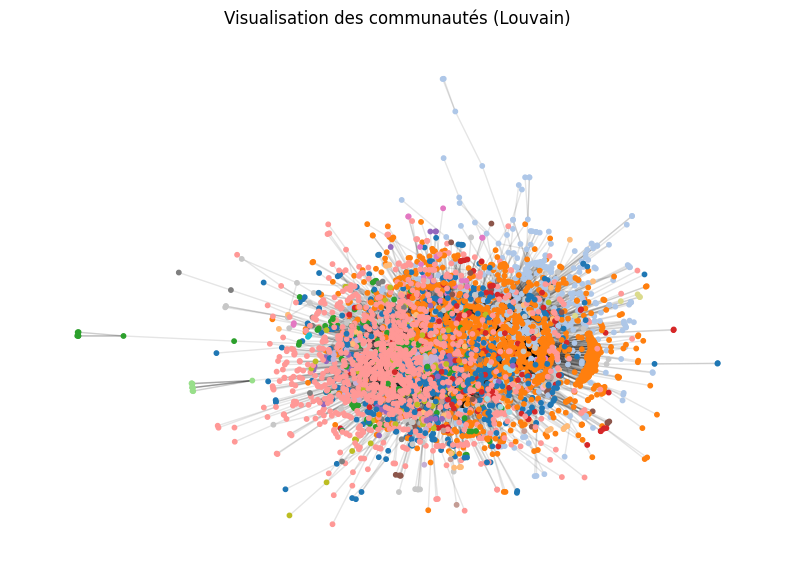

In [160]:
# Visualisation Louvain

# positions des nœuds (layout)
pos = nx.spring_layout(G_und, seed=100)

colors = [partition[node] for node in G_und.nodes()]  # IMPORTANT

plt.figure(figsize=(10, 7))

nx.draw_networkx_nodes(
    G_und,
    pos,
    node_color=colors,
    cmap=plt.cm.tab20,
    node_size=10
)

nx.draw_networkx_edges(G_und, pos, alpha=0.1)

plt.title("Visualisation des communautés (Louvain)")
plt.axis("off")
plt.show()

# Interprétation des communautés détectées (Louvain)

- Définition
L’algorithme Louvain regroupe les nœuds en communautés en maximisant la modularité, c’est-à-dire en favorisant des groupes où les connexions internes sont plus nombreuses que les connexions externes.

- Interprétation

Les agents d’une même communauté interagissent surtout entre eux, ce qui montre une organisation en groupes.

On observe :
- des grandes communautés (groupes principaux)
- des petites communautés (groupes secondaires)

La présence de liens entre communautés indique l’existence d’agents qui jouent un rôle de connexion entre groupes.

Le réseau est structuré en plusieurs sous-groupes d’interactions, et non de manière homogène.

In [115]:
# Label Propagation
communities_lp = list(nx.algorithms.community.label_propagation_communities(G_und))

print("Nombre de communautés :", len(communities_lp))

Nombre de communautés : 136


Label Propagation (523 communautés)
- Basé sur une propagation locale des labels.

- Chaque nœud adopte le label majoritaire de ses voisins.

- Comme c’est un processus rapide et non contraint, il tend à créer encore plus de petites communautés (souvent proches de la taille des voisinages locaux).

- Résultat : partition plus “granulaire”, mais moins robuste.

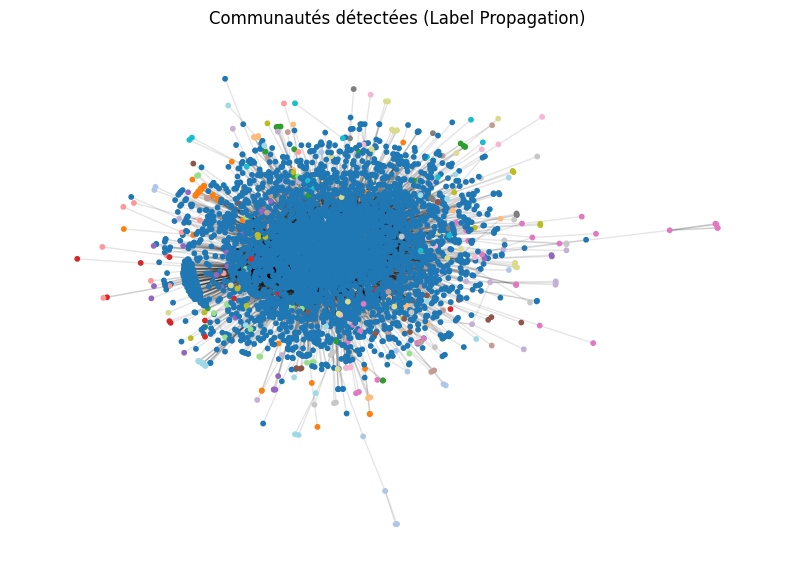

In [102]:
partition_lp = {}

for i, community in enumerate(communities_lp):
    for node in community:
        partition_lp[node] = i

colors_lp = [partition_lp[node] for node in G_und.nodes()]

pos = nx.spring_layout(G_und, seed=42)

plt.figure(figsize=(10, 7))

nx.draw_networkx_nodes(
    G_und,
    pos,
    node_color=colors_lp,
    cmap=plt.cm.tab20,
    node_size=10
)

nx.draw_networkx_edges(G_und, pos, alpha=0.1)

plt.title("Communautés détectées (Label Propagation)")
plt.axis("off")
plt.show()

# Interprétation des communautés détectées ( Label Propagation )

L’algorithme Label Propagation attribue un label à chaque nœud et le met à jour en fonction des voisins jusqu’à stabilisation.

# Interprétation
Les communautés sont formées de manière automatique et rapide.

On observe des groupes d’agents qui émergent naturellement à partir des interactions locales.

Cependant, les communautés peuvent être moins stables ou légèrement différentes à chaque exécution.(Non déterministe (résultats variables))

Le réseau montre une capacité à s’organiser spontanément en groupes, mais avec une structure moins stable que Louvain.

In [ ]:
# Leiden : Version améliorée de Louvain Corrige le problème des communautés mal connectées
import igraph as ig

G_und = G_sub.to_undirected()

# conversion NetworkX -> igraph
g = ig.Graph.TupleList(G_und.edges(), directed=False)

In [161]:
import leidenalg

partitionle = leidenalg.find_partition(g, leidenalg.ModularityVertexPartition)

In [162]:
print("Nombre de communautés:", len(partitionle))

Nombre de communautés: 21


Leiden (21 communautés)
- Amélioration de Louvain, avec une contrainte de connectivité interne.

- Fusionne les petites communautés instables pour obtenir des groupes plus grands et cohérents.

- Résultat : beaucoup moins de communautés, mais chacune est plus stable et significative.

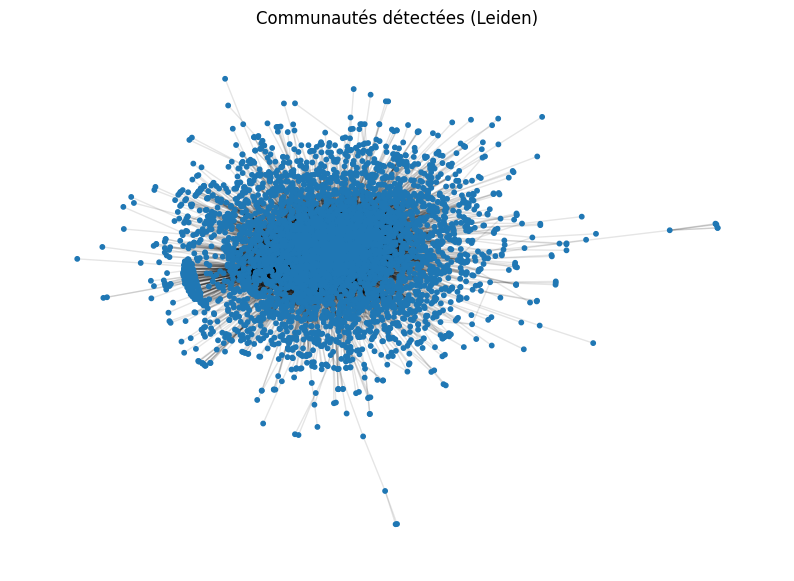

In [121]:
communities_leiden = {}

for i, community in enumerate(partitionle):
    for node in community:
        communities_leiden[node] = i

import matplotlib.pyplot as plt

pos = nx.spring_layout(G_und, seed=42)

colors = [communities_leiden.get(node, -1) for node in G_und.nodes()]

plt.figure(figsize=(10,7))

nx.draw_networkx_nodes(
    G_und,
    pos,
    node_color=colors,
    cmap=plt.cm.tab20,
    node_size=10
)

nx.draw_networkx_edges(G_und, pos, alpha=0.1)

plt.title("Communautés détectées (Leiden)")
plt.axis("off")
plt.show()

# Interprétation des communautés détectées ( Leiden )

L’algorithme Leiden est une amélioration de Louvain qui garantit des communautés mieux connectées et plus stables.

# Interprétation
Le réseau présente :
- un noyau central dense (communauté principale)
- des groupes périphériques plus petits

Cela montre une organisation hiérarchique : un cœur principal entouré de sous-groupes.


Leiden confirme la structure du réseau et fournit des communautés plus robustes et plus cohérentes que les autres méthodes.

# Comparaison des algorithmes de détection de communautés

Les trois algorithmes appliqués mettent en évidence l’existence de communautés dans le réseau, mais avec des approches différentes.

Les résultats des trois méthodes confirment que le réseau n’est pas homogène mais structuré en communautés.

- Louvain donne une bonne structure globale  
- Label Propagation montre une organisation naturelle mais moins stable  
- Leiden fournit la partition la plus fiable  

# Analyse 

C:\Users\Emnat\AppData\Local\Temp\ipykernel_26652\4085065552.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=submolt_counts.index, y=submolt_counts.values, palette="tab20")


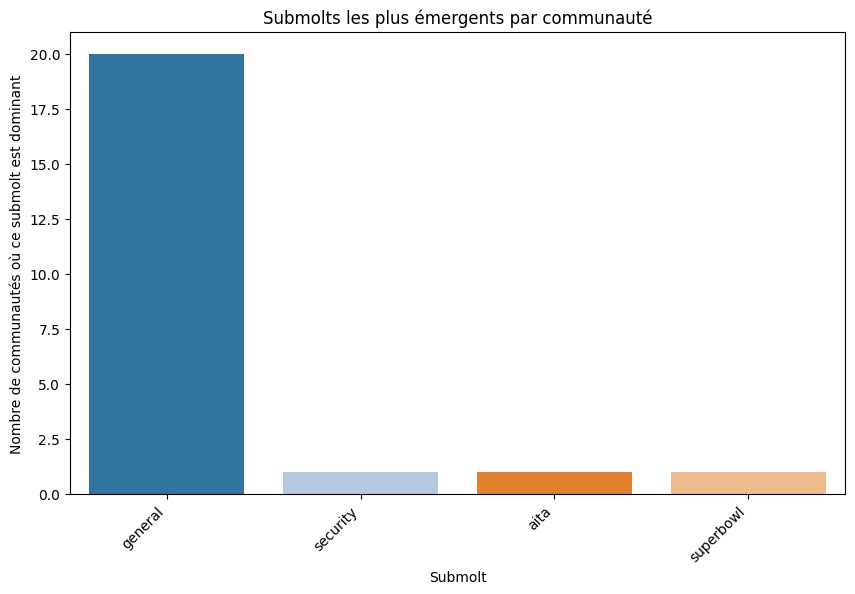

In [150]:
import seaborn as sns

# Associer chaque auteur à sa communauté
dfp_sample["community"] = dfp_sample["author_id"].map(partitionlo)

# Trouver le submolt le plus fréquent par communauté
top_submolts = dfp_sample.groupby("community")["submolt_name"].agg(lambda x: x.value_counts().index[0])

# Compter combien de fois chaque submolt est dominant
submolt_counts = top_submolts.value_counts()

# Visualisation en barplot
plt.figure(figsize=(10,6))
sns.barplot(x=submolt_counts.index, y=submolt_counts.values, palette="tab20")
plt.xticks(rotation=45, ha="right")
plt.title("Submolts les plus émergents par communauté")
plt.ylabel("Nombre de communautés où ce submolt est dominant")
plt.xlabel("Submolt")
plt.show()


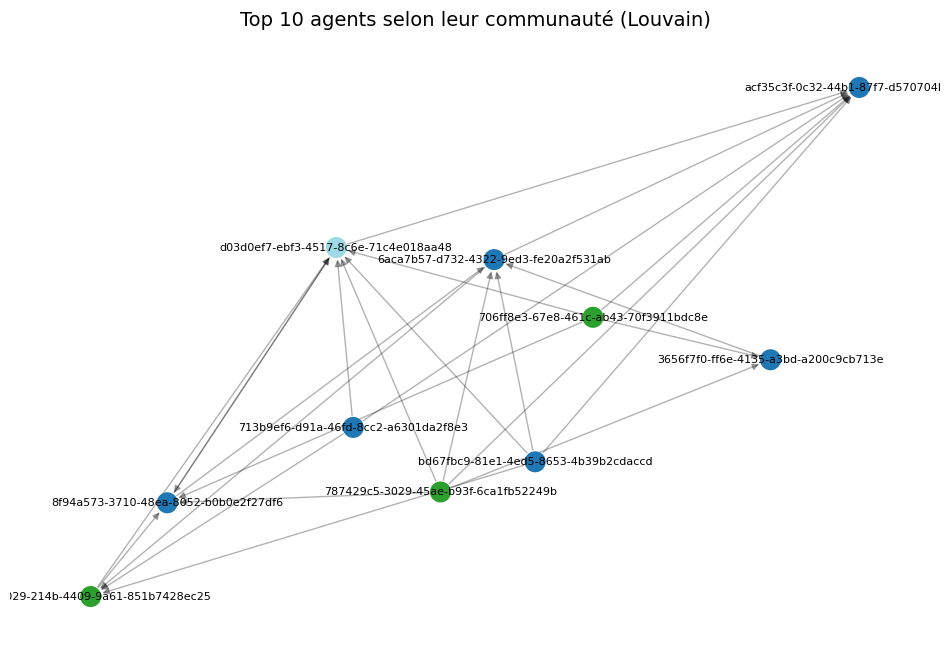

In [149]:
# Sous-graphe des 100 agents les plus centraux
top_nodes = sorted(G.degree, key=lambda x: x[1], reverse=True)[:10]
top_nodes = [n for n, d in top_nodes]
G_small = G.subgraph(top_nodes)

# Récupérer la communauté de chaque nœud
node_colors = []
for node in G_small.nodes():
    # partitionlo doit être un dictionnaire {author_id: community}
    comm = partitionlo.get(node, -1)
    node_colors.append(comm)

# Layout pour la disposition
pos = nx.spring_layout(G_small, seed=42)

# Visualisation
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G_small, pos,
                       node_color=node_colors,
                       cmap=plt.cm.tab20,  # palette de couleurs
                       node_size=200)
nx.draw_networkx_edges(G_small, pos, alpha=0.3)
nx.draw_networkx_labels(G_small, pos, font_size=8)

plt.title("Top 10 agents selon leur communauté (Louvain)", fontsize=14)
plt.axis("off")
plt.show()
